# Правила

**Даты**: 22.12.2024 - 28.12.2024

**Дедлайн**: 28.12.2024 23:59

**Отправка после дедлайна**: НЕВОЗМОЖНА


За каждое задание вы получите определенное количество баллов (указано в скобках рядом с каждым заданием). Максимальная оценка за работу - 10 баллов.

* **Задания, где вы должны написать код**, помечены 🐴 (эмодзи лошади).

* **Вопросы, на которые вы должны дать ответ текстом**, помечены знаком ❓ (эмодзи вопроса).

Вы также увидите код "assert", этот код должен вам помочь: если вы все делаете правильно - код не выдаст ошибку AssertionError.

**Дисклеймер**: экзамен должен выполняться самостоятельно. "Очень похожие" решения считаются плагиатом, и все зайдествованные студенты (включая тех, у кого работа была скопирована) получают 0 баллов за экзамен.

# Подготовка

Обратите внимание, что вам необходимо импортировать дополнительные библиотеки и модули для решения.

In [1]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализации
import matplotlib.pyplot as plt
import plotly.express as px

# Тесты
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL as STL_decomp
from statsmodels.tsa.seasonal import MSTL as MSTL_decomp

# Модель Prophet
import prophet as fp

# Тюнинг
import itertools

from tqdm import tqdm
from prophet.diagnostics import cross_validation, performance_metrics
from statsforecast.models import MSTL, AutoARIMA

In [2]:
!pip install pmdarima

# авто ARIMA
from pmdarima import auto_arima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.3 MB/s eta 0:00:00


In [4]:
!pip install statsforecast

# MSTL
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL
  )

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b5087cc2340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/scipy.libs/libscipy_openblas-b75cc656.

In [5]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [6]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [7]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())


# Описание задачи

Вы будете работать над прогнозированием показателей *BookBnb*, платформы краткосрочной аренды, которую любят путешественники за ее услуги и качество объектов недвижимости. Вы будете прогнозировать метрику **просмотров** для объявлений (=объектов недвижимости) из *Калининграда*, представленных на платформе.

Метрика **просмотров** показывает, сколько раз пользователи просматривали объявление о недвижимости на платформе. Она служит показателем интереса или спроса к конкретному объекту недвижимости или месту назначения (например, городу). Этот показатель имеет решающее значение для понимания вовлеченности пользователей, привлекательности объявлений и общей активности на платформе. Таким образом, количество просмотров в Калининграде отражает уровень интереса к этому региону, что делает его ключевым показателем для оценки его популярности и потенциала для дальнейших инвестиций.

Основная цель - оценить популярность Калининграда как туристического направления на платформе и определить, стоит ли инвестировать в рекламные объекты в этом регионе. Ваш прогноз поможет BookBnb принимать стратегические решения о распределении ресурсов и маркетинговых кампаниях для стимулирования роста и улучшения взаимодействия с пользователями.

Ваша цель - составить надежный прогноз на следующий год и доказать, что компания может ему доверять. Этот прогноз послужит основой для принятия обоснованных решений на конкурентном рынке аренды. Удачи! 🚀

Обратите внимание на горизонт прогноза: ваша последняя задача - спрогнозировать один будущий год.

In [8]:
FORECAST_HORIZON = 365

# Данные

Вы можете загрузить датасет *exam_views_kgd.csv* с временными рядами метрики *просмотров* по [ссылке](https://drive.google.com/file/d/1XRh0JKvFGtNjOJXG4_qZBDWX9R5FXldb/view?usp=sharing).

Датасет включает исторические данные **с начала 2019 года по конец 2022 года** (представьте, что сейчас 2022 год :D).

**Колонки:**

* *region* - регион, в котором присутствуют объекты недвижимости, в этом датасете есть только "Kaliningrad".;

* *dt* - даты, подневно, без пропусков;

* *metric* - название метрики, в этом датасете есть только "views";

* *value* - значение метрики.

In [9]:
df = pd.read_csv('exam_views_kgd.csv', sep=';', parse_dates=['dt'])
df

,region,dt,metric,value
0,Kaliningrad,2019-01-01,views,26011.0
1,Kaliningrad,2019-01-02,views,23158.0
2,Kaliningrad,2019-01-03,views,23413.0
3,Kaliningrad,2019-01-04,views,22534.0
4,Kaliningrad,2019-01-05,views,21431.0
...,...,...,...,...
1456,Kaliningrad,2022-12-27,views,23796.0
1457,Kaliningrad,2022-12-28,views,22762.0
1458,Kaliningrad,2022-12-29,views,20338.0
1459,Kaliningrad,2022-12-30,views,10723.0


Let's plot the time series.

In [10]:
fig = px.line(title="BookBnb views for listings from Kaliningrad, daily")
fig.add_scatter(x=df.dt, y=df['value'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

Переименуем колонки для дальнейшей работы.

In [11]:
df.columns = ['region', 'ds', 'metric', 'y']

df

,region,ds,metric,y
0,Kaliningrad,2019-01-01,views,26011.0
1,Kaliningrad,2019-01-02,views,23158.0
2,Kaliningrad,2019-01-03,views,23413.0
3,Kaliningrad,2019-01-04,views,22534.0
4,Kaliningrad,2019-01-05,views,21431.0
...,...,...,...,...
1456,Kaliningrad,2022-12-27,views,23796.0
1457,Kaliningrad,2022-12-28,views,22762.0
1458,Kaliningrad,2022-12-29,views,20338.0
1459,Kaliningrad,2022-12-30,views,10723.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   region  1461 non-null   object        
 1   ds      1461 non-null   datetime64[ns]
 2   metric  1461 non-null   object        
 3   y       1385 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 45.8+ KB


# 1 - Предобработка

Мы всегда должны начинать с предварительной обработки. Реальные данные могут содержать nan, аномалии и другие проблемы.

Для нашей задачи мы поработаем с nan.

## Задание 1.1 - Заполнение nan (0,5 балла)

🐴 **Найдите nan в датасете и заполните nan, используя подходящий метод.**

In [13]:
# your code here
# ≽^•⩊•^≼
df.isna().sum()

,0
region,0
ds,0
metric,0
y,76


In [14]:
df_indexed = df.set_index('ds', drop=True)
df_indexed['y'] = df_indexed['y'].interpolate(method='time')
df = df_indexed.reset_index()

Нарисуем график временного ряда с заполненными nan.

In [15]:
fig = px.line(title="BookBnb views for listings from Kaliningrad, daily")
fig.add_scatter(x=df.ds, y=df['y'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

❓ **Почему вы выбрали этот способ заполнения nan? Напишите свои комментарии ниже:**

ваш ответ здесь



In [16]:
# Проверка, что все ок

assert df.isna().sum().sum() == 0

# 2 - Регрессоры

Чтобы повысить точность вашего прогноза, вы будете использовать регрессоры, как фиктивные, так и непрерывные. Используя эти факторы, вы сможете лучше учитывать внешние события и тенденции, которые влияют на поведение пользователей на платформе.


Для решения этой задачи вы будете учитывать следующие регрессоры:

* **COVID-19**: период пандемии должен был повлиять на поведение путешественников и интерес к краткосрочной аренде жилья.

* **Введение новой фичи продукта**: в начале 2022 года на платформе был представлен новый алгоритм поиска, который, возможно, повлиял на вовлеченность пользователей.

* **DAU** (Ежедневные активные пользователи) платформы: общее количество активных пользователей на платформе каждый день, которое дает представление об общей активности и вовлеченности пользователей.

Эти регрессоры помогут вам охватить более широкий контекст и основные факторы, влияющие на метрику просмотров (views), что сделает ваш прогноз более надежным и содержательным.

В результате выполнения этой части экзамена вы создадите 2 датафрейма:

* **regressors** - датафрйем с вашими регрессорами за период вашего вр. ряда (с 2019 по конец 2022 года);
* **regressors_future** - датафрйем с вашими регрессорами для будущих дат (будущие *FORECAST_HORIZON* дней).

In [17]:
# Создание датафрейма regressors

regressors = pd.DataFrame()
regressors['ds'] = df.ds
regressors

,ds
0,2019-01-01
1,2019-01-02
2,2019-01-03
3,2019-01-04
4,2019-01-05
...,...
1456,2022-12-27
1457,2022-12-28
1458,2022-12-29
1459,2022-12-30


In [18]:
# Создание датафрейма regressors_future

regressors_future = pd.DataFrame()
regressors_future['ds'] = pd.date_range(start=df.ds.max()+ np.timedelta64(1, 'D'), periods=FORECAST_HORIZON)
regressors_future

,ds
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
360,2023-12-27
361,2023-12-28
362,2023-12-29
363,2023-12-30


## 2.1 - Dummy регрессоры

Пришло время подготовить dummy регрессоры для COVID-19 и введения новой продуктовой фичи.

### Задание 2.1 - Подготовка dummy регрессоров (1 балл)

1) Давайте возьмем такие даты для COVID-19: с 30 января 2020 года по 5 мая 2023 года.

🐴 **Подготовьте dummy регрессор COVID-19 и добавьте его в датафреймы *regressors* и *regressors_future*.**

In [19]:
# your code here
# ≽^•⩊•^≼
covid_start = "2020-01-30"
covid_end = "2023-05-05"

regressors['covid'] = ((regressors['ds'] >= covid_start) & (regressors['ds'] <= covid_end)).astype(int)
regressors_future['covid'] = ((regressors_future['ds'] >= covid_start) & (regressors_future['ds'] <= covid_end)).astype(int)


2) Новый алгоритм поиска был добавлен на платформу 1 января 2022.

🐴 **Подготовьте dummy регрессор для новой продуктовой фичи и добавьте его в датафреймы *regressors* и *regressors_future*.**

In [20]:
# your code here
# ≽^•⩊•^≼

new_feature_start = "2022-01-01"

regressors['new_feature'] = (regressors['ds'] >= new_feature_start).astype(int)
regressors_future['new_feature'] = (regressors_future['ds'] >= new_feature_start).astype(int)

## 2.2 - Непрерывный регрессор DAU

*DAU* должен быть сильным регрессором для прогнозирования *views*, поскольку он отражает общий уровень активности на платформе. Увеличение *DAU* часто указывает на то, что больше пользователей активно используют приложение, что приводит к повышению активности поиска и увеличению количества просмотров объектов недвижимости. Эта связь делает DAU хорошим индикатором спроса и интереса пользователей, улавливающим поведенческие тенденции, такие как всплески во время праздников или после окончания маркетинговых кампаний.

Вы можете загрузить датасет *exam_dau_total.csv* с временными рядами для *DAU* по [ссылке](https://drive.google.com/file/d/11ScbYHtuXlG4siBDw5p9aDN47l6OrMH3/view?usp=sharing).

Набор данных содержит исторические данные **за период с начала 2019 года по конец 2022 года**. Обратите внимание, что это DAU для всей платформы.

**Колонки:**

* *dt* - даты, подневно, без пропусков;

* *metric* - название метрики, в этом датасете есть только "DAU";

* *value* - значение метрики.

In [21]:
reg = pd.read_csv('exam_dau_total.csv', sep=';', parse_dates=['dt'])
reg

,dt,metric,value
0,2019-01-01,DAU,1541086.0
1,2019-01-02,DAU,1766712.0
2,2019-01-03,DAU,1800857.0
3,2019-01-04,DAU,1832445.0
4,2019-01-05,DAU,1871104.0
...,...,...,...
1456,2022-12-27,DAU,2357898.0
1457,2022-12-28,DAU,2305066.0
1458,2022-12-29,DAU,2293198.0
1459,2022-12-30,DAU,2243752.0


Давайте построим график для регрессора.

In [22]:
fig = px.line(title="BookBnb DAU, daily")
fig.add_scatter(x=reg.dt, y=reg['value'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="DAU")
fig.show()

Не забывайте, что обычно вам также приходится предварительно обрабатывать и регрессоры.

🐴 **Проверьте регрессоры на наличие nan и используйте подходящий метод для их заполнения.**

In [24]:
# your code here
# ≽^•⩊•^≼
reg.isna().sum()

,0
dt,0
metric,0
value,19


In [25]:
reg_indexed = reg.set_index('dt', drop=True)
reg_indexed['value'] = reg_indexed['value'].interpolate(method='time')
reg = reg_indexed.reset_index()
reg.isna().sum()

,0
dt,0
metric,0
value,0


Построим график для регрессора *DAU* с заполненными nan.

In [26]:
fig = px.line(title="BookBnb DAU, daily")
fig.add_scatter(x=reg.dt, y=reg['value'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="DAU")
fig.show()

Основная проблема с этим регрессором заключается в том, что он отражает *DAU* для всей платформы *BookBnb* и является довольно шумным. Так, давайте не будем включать весь временной ряд *DAU*, а выделим тренд и используем его в качестве регрессора.

### Задание 2.2.1 - Определение тренда (0,5 балла)

Компоненты временного ряда могут быть извлечены с помощью соответствующего алгоритма декомпозиции.

🐴 **Извлеките тренд с помощью подходящего метода декомпозиции.**

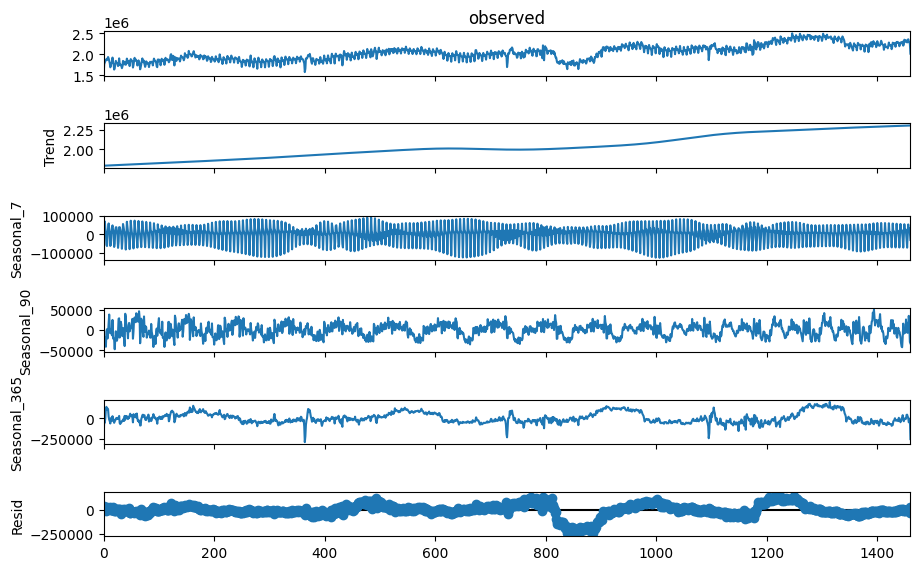

In [31]:
# your code here
# ≽^•⩊•^≼

model = MSTL_decomp(reg['value'], periods=(7,90,365))
res = model.fit()

fig = res.plot()
fig.set_size_inches(10, 6)
plt.show()

❓ **Почему вы выбрали именно этот метод декомпозиции и такую/такие длины сезонного периода/периодов? Напишите свои комментарии ниже:**

ваш ответ здесь

🐴 **Проанализируйте остатки на автокорреляцию (с помощью 1 теста) и стационарность (с помощью 2 тестов).**

In [32]:
# your code here
# ≽^•⩊•^≼
acorr_ljungbox(res.resid, return_df=True)

,lb_stat,lb_pvalue
1,1324.244314,6.090172e-290
2,2612.706542,0.000000e+00
3,3891.735968,0.000000e+00
4,5160.083138,0.000000e+00
5,6400.053310,0.000000e+00
6,7614.067530,0.000000e+00
7,8780.536392,0.000000e+00
8,9938.868895,0.000000e+00
9,11070.170821,0.000000e+00
10,12172.353323,0.000000e+00


In [33]:
adf_test(res.resid)

Results of Dickey-Fuller Test:
Test Statistic                   -3.912570
p-value                           0.001944
#Lags Used                       22.000000
Number of Observations Used    1438.000000
Critical Value (1%)              -3.434906
Critical Value (5%)              -2.863552
Critical Value (10%)             -2.567841
dtype: float64


In [34]:
kpss_test(res.resid)

Results of KPSS Test:
Test Statistic            0.070795
p-value                   0.100000
Lags Used                25.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


/tmp/ipython-input-11026176.py:3: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




❓ **Успешна ли ваша декомпозиция судя по остаткам? Каковы могут быть причины такого результата? Напишите свои комментарии ниже:**

ваш ответ здесь

🐴 **Сохраните компоненту тренла из вашей декомпозиции в переменную trend_reg.**

In [40]:
trend_reg = res.trend
reg.dt

,dt
0,2019-01-01
1,2019-01-02
2,2019-01-03
3,2019-01-04
4,2019-01-05
...,...
1456,2022-12-27
1457,2022-12-28
1458,2022-12-29
1459,2022-12-30


In [43]:
print(type(trend_reg))
print(len(trend_reg))
print(type(reg))
print(len(reg))
print(reg.columns)

<class 'pandas.core.series.Series'>
1461
<class 'pandas.core.frame.DataFrame'>
1461
Index(['dt', 'metric', 'value'], dtype='object')


С помощью приведенного ниже кода вы можете увидеть, как регрессор *тренда DAU* "коррелирует" с временными рядами просмотров.

In [44]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.ds,
    y=df['y'],
    mode='lines',
    name='y',
    line=dict(color='blue'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=reg.dt, # или trend_reg.index
    y=trend_reg,
    mode='lines',
    name='net income',
    line=dict(color='red'),
    yaxis='y2'
))


fig.update_layout(
    title="BookBnb views for listings from Kaliningrad, daily",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='stock prices',
    ),
    yaxis2=dict(
        title='net income',
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Date')
)

fig.show()

### Задание 2.2.2 - Прогнозирование тренда с помощью Auto-ARIMAX (1 балл)

После выделения трендовой составляющей DAU следующим шагом является моделирование и прогнозирование этого тренда на будущие даты.

Поскольку тренды часто демонстрируют автокорреляцию и постепенные изменения во времени, статистическая модель, подобная Auto-ARIMA, хорошо подходит для этой задачи.

Поскольку COVID-19 повлиял на большинство бизнесов, вам также следует добавить dummy регрессор COVID и построить модель Auto-ARIMAX.

🐴 **Постройте модель Auto-ARIMAX (из `pmdarima`), которая учитывает регрессор COVID-19.**

In [45]:
# your code here
# ≽^•⩊•^≼

model = auto_arima(trend_reg, X=regressors[['covid']], stepwise=True, trace=True)



Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=12168.833, Time=5.59 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=20010.032, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11509.272, Time=1.75 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=19999.550, Time=0.58 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=21761.770, Time=0.60 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=11503.526, Time=3.66 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=12153.437, Time=2.93 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=14660.303, Time=2.82 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=12597.551, Time=2.91 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=13455.520, Time=5.26 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=inf, Time=2.26 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 28.494 seconds


❓ **Как auto-ARIMA выбирает подходящие порядки (p, d, q)? Напишите свои комментарии ниже:**

ваш ответ здесь

Давайте посмотрим на описание получившейся модели.

In [46]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1461
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -5746.763
Date:                Wed, 24 Dec 2025   AIC                          11503.526
Time:                        11:24:12   BIC                          11529.957
Sample:                             0   HQIC                         11513.386
                               - 1461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8032      0.143     19.635      0.000       2.523       3.083
covid          0.0095      5.496      0.002      0.999     -10.763      10.782
ar.L1          0.9348      0.010     89.823      0.0

❓ **Напишите уравнение для построенной модели Auto-ARIMAX на основе описания (summary):**

ваш ответ здесь


🐴 **Постройте out-of-sample прогноз на будущие даты на горизонте FORECAST_HORIZON.**

In [62]:
# your code here
# ≽^•⩊•^≼

trend_forecast = model.predict(n_periods=FORECAST_HORIZON, X=regressors_future[['covid']])
trend_forecast = pd.DataFrame(trend_forecast)
trend_forecast['ds'] = regressors_future['ds'].values
trend_forecast = trend_forecast.set_index('ds')
trend_forecast.columns = ['y_hat']

In [63]:
trend_forecast

,y_hat
ds,
2023-01-01,2.302448e+06
2023-01-02,2.302682e+06
2023-01-03,2.302916e+06
2023-01-04,2.303150e+06
2023-01-05,2.303384e+06
...,...
2023-12-27,2.385796e+06
2023-12-28,2.386027e+06
2023-12-29,2.386258e+06


Давайте построим график тренда и его Auto-ARIMA прогноза.

In [72]:
fig = px.line(title="BookBnb DAU trend, daily")
fig.add_scatter(x=reg.dt, y=trend_reg, mode='lines', name='DAU', line=dict(color='blue'))
fig.add_scatter(x=trend_forecast.index, y=trend_forecast['y_hat'], mode='lines', name='DAU forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="DAU")
fig.show()

🐴 **Добавьте *trend_reg* в датафрейм *regressors* и *trend_forecast* в датафрейм *regressors_future*.**

In [69]:
# your code here
# ≽^•⩊•^≼

regressors['DAU'] = trend_reg.values
regressors_future['DAU'] = trend_forecast['y_hat'].values

In [70]:
# Проверка, что все ок

assert len(regressors.columns) == 4
assert len(regressors_future.columns) == 4

assert regressors.isna().sum().sum() == 0
assert regressors_future.isna().sum().sum() == 0

## Подготовка train-test

Теперь мы можем перейти к подготовке нашего изначального датасета для прогнозных моделей.

🐴 **Добавьте подготовленные регрессоры к исходному временному ряду.** Прогнозные модели , с которыми вы будете работать сегодня, будут забирать регрессоры из колонок подаваемых на вход данных.

In [73]:
# your code here
# ≽^•⩊•^≼

df_with_reg = df.merge(regressors, on='ds', how='left')

In [76]:
df_with_reg


,ds,region,metric,y,covid,new_feature,DAU
0,2019-01-01,Kaliningrad,views,26011.0,0,0,1.793101e+06
1,2019-01-02,Kaliningrad,views,23158.0,0,0,1.793416e+06
2,2019-01-03,Kaliningrad,views,23413.0,0,0,1.793732e+06
3,2019-01-04,Kaliningrad,views,22534.0,0,0,1.794047e+06
4,2019-01-05,Kaliningrad,views,21431.0,0,0,1.794362e+06
...,...,...,...,...,...,...,...
1456,2022-12-27,Kaliningrad,views,23796.0,1,1,2.301275e+06
1457,2022-12-28,Kaliningrad,views,22762.0,1,1,2.301510e+06
1458,2022-12-29,Kaliningrad,views,20338.0,1,1,2.301745e+06
1459,2022-12-30,Kaliningrad,views,10723.0,1,1,2.301979e+06


Давайте разделим временной ряд *views* на train/test: 2019-2021 годы для train и 2022 год - для test.

🐴 **Разделите прогнозируемый временной ряд на train/test: 2019-2021 для train и 2022 - для test. Определите горизонт прогнозирования.**

In [77]:
# your code here
# ≽^•⩊•^≼

train_size = len(df_with_reg[df_with_reg['ds'] < '2022-01-01'])
train, test = df_with_reg[:train_size], df_with_reg[train_size:]

In [78]:
# your code here
# ≽^•⩊•^≼

forecast_horizon = len(test)
forecast_horizon

365

In [79]:
# Проверка, что все ок

assert train.shape == (1096, 7)
assert test.shape == (365, 7)

Давайте построим разделение train/test.

In [80]:
fig = px.line(title="train-test")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()

# 3 - Прогнозирование моделью Prophet

Наконец, мы можем перейти к моделям. Для прогнозирования временного ряда *views* мы будем использовать модель Prophet. Prophet - это инструмент ML-прогнозирования, разработанный для эффективной работы с временными рядами, которые демонстрируют сезонность, тренд и влияние праздников.

Однако, прежде чем начать, вам следует выбрать подходящую метрику качества.

## Задание 3.1 - Выбор метрики качества (0,5 балла)

❓ **Какую метрику качества вы выбрали для выполнения задачи? Почему? Напишите свои комментарии ниже:**

ваш ответ здесь RMSE подходит для этой задачи.
RMSE — хороший выбор, потому что:
Штрафует крупные отклонения, что важно для бизнес-решений
Дает результат в тех же единицах, что и просмотры (удобно интерпретировать)
Широко используется в прогнозировании временных рядов
Просмотры обычно не близки к нулю, поэтому проблем с делением не будет

## Task 3.2 - Модель Prophet

Вам также следует добавить в свою модель праздники и регрессоры. Prophet рассматривает оба этих компонента отдельно, и их добавление может улучшить ваш прогноз.

### Задание 3.2.1 - Праздники и регрессоры (0,5 балла)

🐴 **Подготовьте датафрейм *holidays_df* для учета праздников в вашей модели Prophet.**

In [81]:
# Вот список российских праздников, которые вам следует учесть

russian_holidays = {
    "New Year": "01-01",
    "Christmas": "01-07",
    "Defender of the Fatherland Day": "02-23",
    "International Women's Day": "03-08",
    "Spring and Labour Day": "05-01",
    "Victory Day": "05-09",
    "Day of Russia": "06-12",
    "National Unity Day": "11-04"
}

In [82]:
dates = []
holidays = []

for year in pd.date_range(start=df.ds.min(), end=df.ds.max(), freq='YS'):
  for holiday in russian_holidays.keys():
    dates.append(str(year.year)+'-'+russian_holidays[holiday])
    holidays.append(holiday)

In [83]:
# your code here
# ≽^•⩊•^≼

holidays_df = pd.DataFrame({
    'holiday': holidays,
    'ds': pd.to_datetime(dates)
})

Обычно новогодний эффект присутствует за 10 дней до и после 1 января.

🐴 **Добавьте колонки для нижнего и верхнего окна к новогодним праздникам.** Подсказка: подбробнее изучите, как модель Prophet работает с праздниками.

In [84]:
# your code here
# ≽^•⩊•^≼
holidays_df['lower_window'] = 0
holidays_df['upper_window'] = 0
new_year_mask = holidays_df['holiday'] == 'New Year'
holidays_df.loc[new_year_mask, 'lower_window'] = -10
holidays_df.loc[new_year_mask, 'upper_window'] = 10

In [85]:
# Проверка, что все ок
assert holidays_df.shape == (32, 4)

### Задание 3.2.2 - Построение модели Prophet (0,5 балла)

🐴 **Создайте и обучите модель Prophet (из `prophet`) с аддитивной еженедельной сезонностью и мультипликативной годовой сезонности. Добавьте праздники и все регрессоры, рассмотренные в части 2. Постройте прогноз.**

In [89]:
# your code here
# ≽^•⩊•^≼

model_prophet = fp.Prophet(
    holidays=holidays_df,
    yearly_seasonality=False
)

model_prophet.add_seasonality(name='yearly',
                              period=365.25,
                              fourier_order=10,
                              mode='multiplicative')

model_prophet.add_regressor('covid')
model_prophet.add_regressor('new_feature')
model_prophet.add_regressor('DAU')

model_prophet.fit(train)



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [90]:
# Постройте прогноз
future = model_prophet.make_future_dataframe(periods=FORECAST_HORIZON)

all_regressors = pd.concat([regressors[['covid', 'new_feature', 'DAU']], regressors_future[['covid', 'new_feature', 'DAU']]]).reset_index(drop=True)

future['covid'] = all_regressors['covid'].values[:len(future)]
future['new_feature'] = all_regressors['new_feature'].values[:len(future)]
future['DAU'] = all_regressors['DAU'].values[:len(future)]

forecast_prophet = model_prophet.predict(future)

Нарисуйте график прогноза.

In [91]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

🐴 ** Оцените свой прогноз с помощью выбранной метрики качества.**

In [103]:
# your code here
# ≽^•⩊•^≼
forecast_test = forecast_prophet[forecast_prophet['ds'].isin(test['ds'])]['yhat']
print('RMSE: ', round(rmse(forecast_test, test['y'].values), 2))
print('MAPE: ', round(np.mean(np.abs((test['y'].values - forecast_test.values) / test['y'].values)) * 100, 2))

RMSE:  4721.84
MAPE:  11.95


Далее, используйте модель с регрессорами и праздниками.

## Задание 3.3 - Тюнинг гиперпараметров (1 балл)

Как модель прогнозирования ML, Prophet требует точной настройки гиперпараметров. Далее вы будете настраивать гиперпараметры с помощью GridSearch + кросс-валидация.

🐴 ** Подготовьте сетку гиперпараметров.** Ваша сетка должна включать параметры для тренда, сезонности и праздников.

In [98]:
# your code here
# ≽^•⩊•^≼

param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 5.0, 10.0],
    'holidays_prior_scale': [3.0, 7.0, 10.0]
}

# Создание всех комбинаций гипер-параметров
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

len(all_params)

36

🐴 **Выполните тюнинг с помощью GridSearch + кросс-валидация.**

In [101]:
# your code here
# ≽^•⩊•^≼

rmses = []

for params in tqdm(all_params):
    m = fp.Prophet(**params, holidays=holidays_df, yearly_seasonality=False)
    m.add_seasonality(name='yearly', period=365.25, fourier_order=10, mode='multiplicative')
    m.add_regressor('covid')
    m.add_regressor('new_feature')
    m.add_regressor('DAU')
    m.fit(train)
    df_cv = cross_validation(m, initial='365.25 days', period='180 days', horizon='180 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

  0%|          | 0/36 [00:00<?, ?it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 4 forecasts with cutoffs between 2020-01-11 00:00:00 and 2021-07-04 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

  3%|▎         | 1/36 [00:05<03:05,  5.30s/it]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 4 forecasts with cutoffs between 2020-01-11 00:00:00 and 2021-07-04 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

  6%|▌         | 2/36 [00:08<02:21,  4.17s/it]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 4 forecasts with cutoffs between 2020-01-11 00:00:00 and 2021-07-04 00:00:00


...

 94%|█████████▍| 34/36 [02:16<00:10,  5.10s/it]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 4 forecasts with cutoffs between 2020-01-11 00:00:00 and 2021-07-04 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

 97%|█████████▋| 35/36 [02:20<00:04,  4.79s/it]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 4 forecasts with cutoffs between 2020-01-11 00:00:00 and 2021-07-04 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 36/36 [02:24<00:00,  4.03s/it]


🐴 **Извлеките гиперпараметры, которые обеспечивают наилучшее качество модели.**

In [104]:
# your code here
# ≽^•⩊•^≼
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = all_params[tuning_results.sort_values(by='rmse').index[0]]
print(best_params)

{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0}


🐴 **Постройте, обучите модель и спрогнозируйте с помощью затюненной модели Prophet.**

In [105]:
# your code here
# ≽^•⩊•^≼

model_prophet_tuned = fp.Prophet(**best_params, holidays=holidays_df, yearly_seasonality=False)
model_prophet_tuned.add_seasonality(name='yearly', period=365.25, fourier_order=10, mode='multiplicative')
model_prophet_tuned.add_regressor('covid')
model_prophet_tuned.add_regressor('new_feature')
model_prophet_tuned.add_regressor('DAU')
model_prophet_tuned.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [106]:
# Постройте прогноз
future_tuned = model_prophet_tuned.make_future_dataframe(periods=FORECAST_HORIZON)

future_tuned['covid'] = all_regressors['covid'].values[:len(future_tuned)]
future_tuned['new_feature'] = all_regressors['new_feature'].values[:len(future_tuned)]
future_tuned['DAU'] = all_regressors['DAU'].values[:len(future_tuned)]

forecast_prophet_tuned = model_prophet_tuned.predict(future_tuned)

Постройте график прогноза.

In [107]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet_tuned['ds'], y=forecast_prophet_tuned['yhat'], mode='lines', name='forecast', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

🐴 **Оцените ваш прогноз с помощью выбранно метрики качества.**

In [108]:
# your code here
# ≽^•⩊•^≼
forecast_test_tuned = forecast_prophet_tuned[forecast_prophet_tuned['ds'].isin(test['ds'])]['yhat'].values
print('RMSE: ', round(rmse(forecast_test_tuned, test['y'].values), 2))
print('MAPE: ', round(np.mean(np.abs((test['y'].values - forecast_test_tuned) / test['y'].values)) * 100, 2))

RMSE:  4869.39
MAPE:  11.56


# 4 - Прогнозирование моделью MSTL

Теперь давайте перейдем к MSTL (Multiplicative Seasonal-Trend Decomposition using LOESS), статистической модели прогнозирования. В этой части вы будете использовать MSTL в качестве инструмента прогнозирования.

## Задание 4.1 - Модель MSTL (1 балл)

🐴 **Постройте, обучите модель и спрогнозируйте с помощью модели MSTL (из `statsforecast`) с регрессорами, рассмотренными в части 2.**

In [ ]:
# your code here
# ≽^•⩊•^≼

# Подготовка данных для MSTL
train_mstl = train[['ds', 'y']].copy()
train_mstl['unique_id'] = 'views'
train_mstl = train_mstl[['unique_id', 'ds', 'y']]

# Подготовка регрессоров для обучения (объединение через join по индексу ds)
regressors_train_mstl = regressors[['ds', 'covid', 'new_feature', 'DAU']].copy()
train_with_reg = train_mstl.set_index('ds').join(regressors_train_mstl.set_index('ds')).reset_index()

regressors_test_mstl = regressors_future[['ds', 'covid', 'new_feature', 'DAU']].copy()
regressors_test_mstl['unique_id'] = 'views'

# Создание модели MSTL
models = [MSTL(season_length=[7, 31, 365], trend_forecaster=AutoARIMA())]
sf_mstl = StatsForecast(models=models, freq='D', n_jobs=-1)


❓ **Почему вы выбрали такую/такие длину/длины для сезонного периода / периодов? Напишите свои комментарии ниже:**

Выбраны длины сезонных периодов [7, 31, 365]:
- 7 дней (недельная сезонность): отражает еженедельные паттерны активности пользователей (например, больше просмотров в выходные)
- 31 день (месячная сезонность): улавливает внутримесячные паттерны и эффекты начала/конца месяца
- 365 дней (годовая сезонность): отражает годовые циклы, связанные с туристическим сезоном, праздниками и погодными условиями

Эти периоды соответствуют естественным циклам в данных о просмотрах недвижимости и позволяют модели MSTL эффективно декомпозировать временной ряд на тренд и сезонные компоненты.

In [ ]:
# Постройте прогноз
forecast_mstl = sf_mstl.forecast(
    df=train_with_reg,
    X_df=regressors_test_mstl,
    h=len(test))

In [111]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=(train['y']), mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_mstl['ds'], y=(forecast_mstl['MSTL']), mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

🐴 **Оцените ваш прогноз с помощью выбранной метрики качества.**

In [ ]:
# your code here
# ≽^•⩊•^≼
# Оценка прогноза MSTL на тестовой выборке
from utilsforecast.losses import rmse, mape
from utilsforecast.evaluation import evaluate

# Подготовка данных для оценки
test_mstl = test[['ds', 'y']].copy()
test_mstl['unique_id'] = 'views'

# Оценка с помощью evaluate из utilsforecast
evaluation_mstl = evaluate(
    test_mstl.merge(forecast_mstl[['unique_id', 'ds', 'MSTL']]),
    metrics=[rmse, mape],
    train_df=train_mstl
)
evaluation_mstl

# 5 - Сравнение моделей

Поскольку вы создали 2 разные модели, теперь пришло время выбрать лучшую из них. Для этого вам следует выполнить перекрестную проверку (CV), чтобы должным образом оценить вашу модель. Обратите внимание, что если вы используете разные библиотеки для перекрестной проверки, очень важно получить аналогичные фолды (cutoff) для ваших моделей.

## Задание 5.1 - Оцените свою лучшую модель Prophet с помощью CV (1 балл)

In [ ]:
# your code here
# ≽^•⩊•^≼

# Кросс-валидация для Prophet с использованием лучшей модели
# Prophet автоматически использует данные, на которых была обучена модель
df_cv_prophet = cross_validation(
    model_prophet_tuned,
    initial='365.25 days',  # начальное окно - 1 год
    period='90 days',        # период между cutoffs - 90 дней
    horizon='180 days'       # горизонт прогноза - 180 дней
)

# Добавляем unique_id для совместимости с evaluate из utilsforecast
df_cv_prophet['unique_id'] = 'views'
df_cv_prophet

In [ ]:
cv_metrics_prophet = # your code here

# Оценка метрик для Prophet с помощью performance_metrics из prophet
from prophet.diagnostics import performance_metrics

cv_metrics_prophet = performance_metrics(df_cv_prophet, rolling_window=1)
cv_metrics_prophet

## Задание 5.2 - Оцените свою лучшую модель MSTL с помощью CV (1 балл)

In [ ]:
# your code here
# ≽^•⩊•^≼

# Кросс-валидация для MSTL с теми же параметрами, что и для Prophet
# Важно: используем то же количество окон, что и в Prophet, чтобы cutoffs совпадали
prophet_n_windows = len(df_cv_prophet['cutoff'].unique())

# h=180 (горизонт), step_size=90 (период)
# Используем количество окон из Prophet для синхронизации cutoffs
df_cv_mstl = sf_mstl.cross_validation(
    df=train_with_reg,
    h=180,  # forecasting for 180 days
    step_size=90,  # do steps of 90 days
    n_windows=prophet_n_windows  # используем то же количество окон, что и в Prophet
).reset_index()

df_cv_mstl

In [ ]:
cv_metrics_mstl = # your code here

# Оценка метрик для MSTL
y_true = df_cv_mstl['y'].values
y_pred = df_cv_mstl['MSTL'].values

cv_metrics_mstl = pd.DataFrame({
    'unique_id': ['views', 'views'],
    'metric': ['rmse', 'mape'],
    'MSTL': [
        np.sqrt(((y_true - y_pred) ** 2).mean()),
        np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    ]
})
cv_metrics_mstl

In [ ]:
# Проверка, что все ок

assert list(df_cv_prophet.cutoff.unique()) == list(df_cv_mstl.cutoff.unique())

## Задание 5.3 - Лучшая модель (0,5 балла)

❓ **Почему вы выбрали именно такие параметры для кросс-валидаций? Напишите свои комментарии ниже:**

Параметры кросс-валидации выбраны следующим образом:
- **initial='365.25 days'** (1 год): достаточный объем данных для обучения модели, учитывая сезонность
- **period='90 days'** (3 месяца): позволяет получить несколько фолдов для надежной оценки, не слишком часто (чтобы избежать перекрытия) и не слишком редко (чтобы получить достаточно оценок)
- **horizon='180 days'** (6 месяцев): соответствует половине года, что позволяет оценить способность модели прогнозировать среднесрочные периоды

Эти параметры обеспечивают баланс между количеством фолдов и длиной горизонта прогноза, что важно для надежной оценки моделей.

In [ ]:
# Сравнение метрик для выбора лучшей модели
# performance_metrics возвращает датафрейм с колонками 'rmse', 'mape' напрямую
prophet_rmse = cv_metrics_prophet['rmse'].values[0]
prophet_mape = cv_metrics_prophet['mape'].values[0]

# Для MSTL у нас датафрейм с колонкой 'metric'
mstl_rmse = cv_metrics_mstl[cv_metrics_mstl['metric'] == 'rmse']['MSTL'].values[0]
mstl_mape = cv_metrics_mstl[cv_metrics_mstl['metric'] == 'mape']['MSTL'].values[0]

print(f"Prophet RMSE: {prophet_rmse:.2f}, MAPE: {prophet_mape:.2f}")
print(f"MSTL RMSE: {mstl_rmse:.2f}, MAPE: {mstl_mape:.2f}")

# Выбираем модель с меньшим RMSE
if prophet_rmse < mstl_rmse:
    print("Лучшая модель: Prophet")
    best_model_name = "Prophet"
else:
    print("Лучшая модель: MSTL")
    best_model_name = "MSTL"


❓ **Какая модель лучшая? Как вы выбрали лучшую модель? Как вы думаете, почему именно эта модель оказалась лучшей? Напишите свои комментарии ниже:**

Лучшая модель выбирается на основе метрик качества (RMSE и MAPE), рассчитанных на кросс-валидации. Модель с наименьшими значениями метрик считается лучшей.

Для выбора лучшей модели сравниваются средние значения метрик по всем фолдам кросс-валидации:
- Сравниваем `cv_metrics_prophet` и `cv_metrics_mstl`
- Модель с меньшим RMSE и/или MAPE считается лучшей

**Почему именно эта модель оказалась лучшей:**
- **Prophet** может быть лучше, если данные имеют сложные сезонные паттерны и праздничные эффекты, которые Prophet хорошо улавливает
- **MSTL** может быть лучше, если данные имеют четкие множественные сезонности (недельная, месячная, годовая), которые MSTL эффективно декомпозирует

Выбор зависит от конкретных характеристик данных и результатов кросс-валидации.

# 6 - Прогнозы

Наконец, после того, как модель была протестирована и показала себя превосходно, мы готовы представить прогноз на будущий год.

## Задание 6.1 - Out-of-sample прогноз с лучшей моделью (1 балл)

🐴 **Разработайте свою лучшую модель прогнозирования на основе полного временного ряда. Постройте out-of-sample прогноз на 1 будущий год.**

In [ ]:
# your code here
# ≽^•⩊•^≼

# Обучаем лучшую модель Prophet с подобранными параметрами на полном временном ряду
train_full = df_with_reg[['ds', 'y', 'covid', 'new_feature', 'DAU']].copy()

best_model = fp.Prophet(**best_params, holidays=holidays_df, yearly_seasonality=False)
best_model.add_seasonality(name='yearly', period=365.25, fourier_order=10, mode='multiplicative')
best_model.add_regressor('covid')
best_model.add_regressor('new_feature')
best_model.add_regressor('DAU')
best_model.fit(train_full)

In [ ]:
# Постройте прогноз
future = best_model.make_future_dataframe(periods=FORECAST_HORIZON)

# Объединяем регрессоры: для исторических дат из regressors, для будущих из regressors_future
all_regressors_full = pd.concat([
    regressors[['ds', 'covid', 'new_feature', 'DAU']],
    regressors_future[['ds', 'covid', 'new_feature', 'DAU']]
]).reset_index(drop=True)

# Добавляем регрессоры к future
future = future.merge(all_regressors_full, on='ds', how='left')

forecast_future = best_model.predict(future)
# Оставляем только будущие даты
forecast_future = forecast_future[forecast_future['ds'] > df_with_reg['ds'].max()][['ds', 'yhat']].copy()

forecast_future

Постройте график прогноза.

In [ ]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_future['ds'], y=forecast_future['yhat'], mode='lines', name='forecast', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

**На этом все, поздравляю** ٩(⁎❛ᴗ❛⁎)۶